<a href="https://colab.research.google.com/github/LuzMRB/TradingMVP/blob/main/ENV_POC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sys

# Only execute if the Python version is NOT 3.9
if not (sys.version_info.major == 3 and sys.version_info.minor == 9):
  # Download and execute set up script
  !wget -O py39.sh https://raw.githubusercontent.com/j3soon/colab-python-version/main/scripts/py39.sh
  !bash py39.sh
else:
  print("Python 3.9 detected. Skipping setup script.")

Python 3.9 detected. Skipping setup script.


In [3]:
import sys
print(sys.version)

3.9.21 (main, Dec 11 2024, 16:24:11) 
[GCC 11.2.0]


**Please refresh this page by pressing F5, and then execute the following cell without running the first one.**

## Preparacion del entorno

In [1]:
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    !pip install -q "setuptools==65.5.0"
    !pip install -q "numpy==1.23.5" "pandas==1.2.4" "scipy==1.10.0" "coloredlogs==15.0.1" "psutil==5.8.0" "termcolor" "pomegranate==0.14.6" "gym==0.26.2"
    !pip install -q torch --index-url https://download.pytorch.org/whl/cpu
    !pip install -q "matplotlib==3.7.5" seaborn tqdm

    !git clone https://github.com/DiegoCG1013/TradingMVP.git /content/TradingMVP 2>/dev/null || echo 'ya clonado'
    %cd /content/TradingMVP
    !git submodule update --init --recursive

    # Abides va primero — tira de grpcio y protobuf nuevos, los sobreescribiremos después
    !pip install -q -e abides-jpmc-public/abides-core
    !pip install -q -e abides-jpmc-public/abides-markets
    !pip install -q -e abides-jpmc-public/abides-gym

    # Dependencias de ray + ray sin deps
    !pip install -q "click<=8.0.4" "virtualenv" "msgpack>=1.0.0,<2.0.0"
    !pip install -q "grpcio==1.43.0" --force-reinstall
    !pip install -q "ray==1.13.0" "ray[rllib]==1.13.0" --no-deps
    !pip install -q aiohttp aiohttp_cors aiosignal colorful jsonschema opencensus prometheus_client pydantic requests tensorboardX

    # Protobuf al final — lo sobreescribimos todo
    !pip install -q "protobuf==3.20.3" --force-reinstall

    import sys
    sys.path.insert(0, '/content/TradingMVP')
    os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

print('Entorno listo')

ya clonado
/content/TradingMVP
  Preparing metadata (setup.py) ... done
  DEPRECATION: Legacy editable install of abides-core==0.0.0 from file:///content/TradingMVP/abides-jpmc-public/abides-core (setup.py develop) is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457
  Preparing metadata (setup.py) ... done
  DEPRECATION: Legacy editable install of abides-markets==0.0.0 from file:///content/TradingMVP/abides-jpmc-public/abides-markets (setup.py develop) is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is

# POC

In [6]:
from abides_markets.configs import rmsc04
from abides_core import abides

config_state = rmsc04.build_config(seed = 0, end_time = '10:00:00')
end_state = abides.run(config_state)

[15888] INFO abides Simulation Start Time: 2026-05-11 12:54:17.112176
[15888] INFO abides_core.kernel --- Simulation time: 2021-02-05 00:00:00, messages processed: 0, wallclock elapsed: 0.00s ---
[15888] INFO abides_core.kernel Event Queue elapsed: 0:00:03.260910, messages: 60,130, messages per second: 18439.6
[15888] INFO abides_core.kernel Mean ending value by agent type:
[15888] INFO abides_core.kernel NoiseAgent: 27
[15888] INFO abides_core.kernel ValueAgent: 494
[15888] INFO abides_core.kernel AdaptivePOVMarketMakerAgent: -7349
[15888] INFO abides_core.kernel MomentumAgent: -5254
[15888] INFO abides_core.kernel Simulation ending!
[15888] INFO abides Simulation End Time: 2026-05-11 12:54:22.673557
[15888] INFO abides Time taken to run simulation: 0:00:05.561381


In [2]:
from src.env.spy_gym_env import SpyGymEnv

env = SpyGymEnv(
    background_config="rmsc04",
    mkt_close="10:00:00",
    timestep_duration="60s",
    starting_cash=1_000_000,
    order_fixed_size=10,
    first_interval="00:05:00",
)

obs = env.reset()

print(f"observation_space: {env.observation_space}")
print(f"action_space:      {env.action_space}")
print(f"obs shape:         {obs.shape}")
print(f"obs:               {obs}")
assert obs.shape == (8,), f"Esperado (8,) pero got {obs.shape}"
print("\nOK — shape correcto")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


observation_space: Box(-3.4028235e+38, 3.4028235e+38, (8,), float32)
action_space:      Discrete(3)
obs shape:         (8,)
obs:               [9.99610e-01 3.10000e-01 9.99620e-01 1.00000e+00 0.00000e+00 1.00000e+00
 9.99615e-01 1.00000e-05]

OK — shape correcto


In [3]:
# Política aleatoria: 1 episodio completo
import numpy as np

obs = env.reset()
done = False
rewards = []

while not done:
    action = env.action_space.sample()
    obs, reward, done, info = env.step(action)
    rewards.append(reward)

print(f"Steps:        {len(rewards)}")
print(f"Reward total: {sum(rewards):.4f}")
print(f"Reward medio: {np.mean(rewards):.6f}")
print("OK — episodio completo sin errores")


Steps:        26
Reward total: -223.4000
Reward medio: -8.592308
OK — episodio completo sin errores


In [4]:
# Loop PPO (500 steps)
from src.training.ppo_trainer import PPOTrainer

env2 = SpyGymEnv(
    background_config="rmsc04",
    mkt_close="10:00:00",
    timestep_duration="60s",
    starting_cash=1_000_000,
    order_fixed_size=10,
    first_interval="00:05:00",
)

trainer = PPOTrainer(
    env=env2,
    rollout_length=50,
    batch_size=25,
    update_epochs=2,
    device="cpu",
)

print(f"obs_dim:   {env2.observation_space.shape[0]}")
print(f"n_actions: {env2.action_space.n}")

trainer.train(total_steps=500, log_interval=1)
print("\nOK — loop PPO completado sin errores")

obs_dim:   8
n_actions: 3
Steps:       50 | Updates:    1 | Avg Reward: -150.000 | Policy Loss:  -0.0040 | Value Loss: 3245.8978 | Entropy:  1.098 | FPS:      7
Steps:      100 | Updates:    2 | Avg Reward:  -86.000 | Policy Loss:  -0.0030 | Value Loss: 1681.6088 | Entropy:  1.097 | FPS:      6
Steps:      150 | Updates:    3 | Avg Reward:  -60.860 | Policy Loss:  -0.0020 | Value Loss: 7707.9701 | Entropy:  1.094 | FPS:      6
Steps:      200 | Updates:    4 | Avg Reward:  -33.929 | Policy Loss:   0.0004 | Value Loss: 236.1557 | Entropy:  1.094 | FPS:      6
Steps:      250 | Updates:    5 | Avg Reward:  -27.311 | Policy Loss:  -0.0002 | Value Loss: 1666.0321 | Entropy:  1.095 | FPS:      7
Steps:      300 | Updates:    6 | Avg Reward:  -17.920 | Policy Loss:  -0.0009 | Value Loss: 3409.5594 | Entropy:  1.092 | FPS:      7
Steps:      350 | Updates:    7 | Avg Reward:  -14.080 | Policy Loss:  -0.0009 | Value Loss: 6181.6476 | Entropy:  1.088 | FPS:      7
Steps:      400 | Updates:    

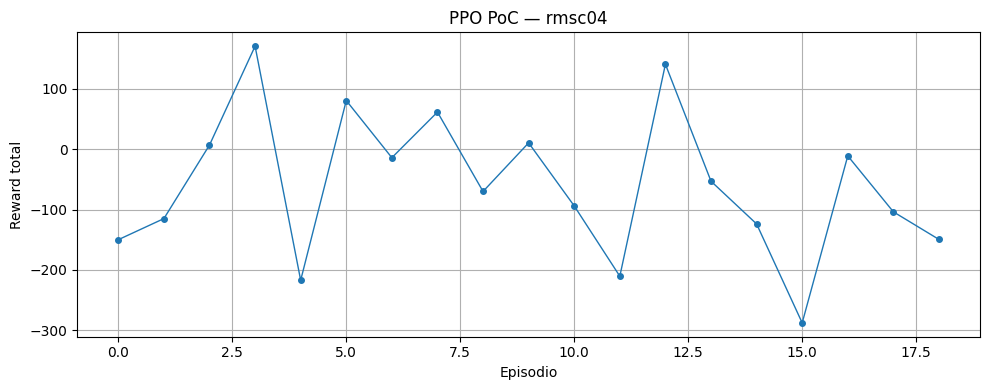

Episodios: 19,  Reward medio: -59.37


In [5]:
# Plot
import matplotlib.pyplot as plt
import numpy as np

rewards_ep = trainer.episode_rewards

if rewards_ep:
    plt.figure(figsize=(10, 4))
    plt.plot(rewards_ep, marker='o', linewidth=1, markersize=4)
    plt.xlabel("Episodio")
    plt.ylabel("Reward total")
    plt.title("PPO PoC — rmsc04")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print(f"Episodios: {len(rewards_ep)},  Reward medio: {np.mean(rewards_ep):.2f}")
else:
    print("No se completaron episodios en 500 steps")
    print(f"Reward parcial: {trainer.current_episode_reward:.2f}")